# Proyecto Final - Notebook 04
## Calibracion fina del mejor candidato `LSTM`

Este notebook hace un ajuste fino sobre el mejor resultado del notebook 03.

Motivacion:
- en la calibracion inicial `lstm_256` fue el mejor candidato,
- por tanto, ahora conviene explorar hiperparametros cercanos en lugar de abrir familias completamente nuevas,
- esto mantiene la calibracion controlada y defendible dentro de la metodologia del curso.

Estrategia de calibracion fina:
1. fijar el encoder visual `MobileNetV2`,
2. fijar el mismo preprocesamiento y las mismas features,
3. variar pocos hiperparametros relevantes del decoder `LSTM`:
   - `learning_rate`,
   - `dropout`,
   - `recurrent_units`.

Criterio de seleccion:
1. menor `val_loss`,
2. mejor `BLEU` si los resultados son cercanos,
3. tiempo de entrenamiento como costo computacional.


In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path
import json
import os
import pickle
import time
from tempfile import gettempdir

os.environ.setdefault('MPLCONFIGDIR', str(Path(gettempdir()) / 'matplotlib-cache-project-final'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.image import imread
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Add, Dense, Dropout, Embedding, Input, LSTM
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.utils import Sequence

In [3]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
IMG_DIR = ROOT / 'data' / 'raw' / 'Images'
MODELS_DIR = ROOT / 'models'
OUTPUT_DIR = ROOT / 'outputs' / 'predictions'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CAPTIONS_CLEAN_PATH = PROCESSED_DIR / 'captions_clean_split.csv'
SUMMARY_PATH = PROCESSED_DIR / 'preprocessing_summary.json'
TOKENIZER_JSON_PATH = PROCESSED_DIR / 'tokenizer.json'
FEATURES_PATH = PROCESSED_DIR / 'image_features_mobilenetv2.pkl'

if not FEATURES_PATH.exists():
    raise FileNotFoundError('No existe image_features_mobilenetv2.pkl. Primero corre el notebook 02.')

print('ROOT =', ROOT)
print('FEATURES_PATH =', FEATURES_PATH)
print('TOKENIZER_JSON_PATH =', TOKENIZER_JSON_PATH)

ROOT = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning
FEATURES_PATH = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/data/processed/image_features_mobilenetv2.pkl
TOKENIZER_JSON_PATH = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/data/processed/tokenizer.json


In [4]:
df = pd.read_csv(CAPTIONS_CLEAN_PATH)
with open(SUMMARY_PATH, 'r', encoding='utf-8') as f:
    preprocessing_summary = json.load(f)
with open(FEATURES_PATH, 'rb') as f:
    image_features = pickle.load(f)

tokenizer = tokenizer_from_json(TOKENIZER_JSON_PATH.read_text(encoding='utf-8'))

vocab_size = len(tokenizer.word_index) + 1
max_len = int(preprocessing_summary['max_len'])
feature_dim = len(next(iter(image_features.values())))

train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

print('train captions =', len(train_df))
print('val captions =', len(val_df))
print('test captions =', len(test_df))
print('vocab_size =', vocab_size)
print('max_len =', max_len)
print('feature_dim =', feature_dim)

train captions = 28315
val captions = 6065
test captions = 6075
vocab_size = 7251
max_len = 38
feature_dim = 1280


## 1. Construccion de muestras

Se mantiene exactamente el mismo esquema supervisado del baseline y de la calibracion inicial.
Asi la comparacion se concentra en los hiperparametros del decoder y no en cambios del pipeline.

In [5]:
def build_next_word_samples(dataframe, tokenizer):
    samples = []
    for row in dataframe.itertuples(index=False):
        seq = tokenizer.texts_to_sequences([row.caption_clean])[0]
        for i in range(1, len(seq)):
            samples.append((row.image, seq[:i], seq[i]))
    return samples


class CaptionDataGenerator(Sequence):
    def __init__(self, samples, image_features, max_len, batch_size=256, shuffle=True):
        self.samples = samples
        self.image_features = image_features
        self.max_len = max_len
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(samples))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_samples = [self.samples[i] for i in batch_indices]

        batch_image = np.array([self.image_features[img_name] for img_name, _, _ in batch_samples], dtype='float32')
        batch_seq = pad_sequences([seq for _, seq, _ in batch_samples], maxlen=self.max_len, padding='post')
        batch_y = np.array([next_word for _, _, next_word in batch_samples], dtype='int32')

        return (batch_image, batch_seq), batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_samples = build_next_word_samples(train_df, tokenizer)
val_samples = build_next_word_samples(val_df, tokenizer)

batch_size = 256
train_gen = CaptionDataGenerator(train_samples, image_features, max_len, batch_size=batch_size, shuffle=True)
val_gen = CaptionDataGenerator(val_samples, image_features, max_len, batch_size=batch_size, shuffle=False)

print('train_samples =', len(train_samples))
print('val_samples =', len(val_samples))
print('train steps =', len(train_gen))
print('val steps =', len(val_gen))

train_samples = 334223
val_samples = 71767
train steps = 1306
val steps = 281


## 2. Configuraciones a comparar

Se prueban cuatro variantes razonables y cercanas al mejor candidato anterior:
- `lstm_256_base`: reproduce el mejor candidato previo,
- `lstm_256_lowlr`: tasa de aprendizaje menor para una optimizacion mas estable,
- `lstm_256_lowdrop`: menor regularizacion para no penalizar tanto la capacidad del decoder,
- `lstm_384_lowlr`: mayor capacidad del decoder con aprendizaje mas conservador.


In [6]:
configs = [
    {'name': 'lstm_256_base', 'recurrent_units': 256, 'embedding_dim': 256, 'dropout_rate': 0.3, 'learning_rate': 1e-3},
    {'name': 'lstm_256_lowlr', 'recurrent_units': 256, 'embedding_dim': 256, 'dropout_rate': 0.3, 'learning_rate': 5e-4},
    {'name': 'lstm_256_lowdrop', 'recurrent_units': 256, 'embedding_dim': 256, 'dropout_rate': 0.2, 'learning_rate': 1e-3},
    {'name': 'lstm_384_lowlr', 'recurrent_units': 384, 'embedding_dim': 256, 'dropout_rate': 0.3, 'learning_rate': 5e-4},
]

epochs = 8
patience = 3

pd.DataFrame(configs)

,name,recurrent_units,embedding_dim,dropout_rate,learning_rate
0,lstm_256_base,256,256,0.3,0.0010
1,lstm_256_lowlr,256,256,0.3,0.0005
2,lstm_256_lowdrop,256,256,0.2,0.0010
3,lstm_384_lowlr,384,256,0.3,0.0005


In [7]:
def build_caption_model(feature_dim, vocab_size, max_len, embedding_dim, recurrent_units, dropout_rate, learning_rate):
    image_input = Input(shape=(feature_dim,), name='image_features')
    image_branch = Dropout(dropout_rate)(image_input)
    image_branch = Dense(recurrent_units, activation='relu')(image_branch)

    seq_input = Input(shape=(max_len,), name='partial_caption')
    seq_branch = Embedding(vocab_size, embedding_dim, mask_zero=True, name='caption_embedding')(seq_input)
    seq_branch = Dropout(dropout_rate)(seq_branch)
    seq_branch = LSTM(recurrent_units, name='caption_lstm')(seq_branch)

    decoder = Add()([image_branch, seq_branch])
    decoder = Dense(recurrent_units, activation='relu')(decoder)
    output = Dense(vocab_size, activation='softmax', name='next_word')(decoder)

    model = Model(inputs=[image_input, seq_input], outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy']
    )
    return model

## 3. Entrenamiento y seleccion preliminar

Se usa `EarlyStopping` sobre `val_loss` para detener el entrenamiento cuando el modelo deja de mejorar en validacion.
Esto esta alineado con la estrategia de calibracion vista en el curso.

In [8]:
results = []
histories = {}
trained_model_paths = {}

for cfg in configs:
    tf.keras.backend.clear_session()
    print(f"\n=== Entrenando {cfg['name']} ===")

    model = build_caption_model(
        feature_dim=feature_dim,
        vocab_size=vocab_size,
        max_len=max_len,
        embedding_dim=cfg['embedding_dim'],
        recurrent_units=cfg['recurrent_units'],
        dropout_rate=cfg['dropout_rate'],
        learning_rate=cfg['learning_rate']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )

    start_time = time.perf_counter()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    elapsed_sec = time.perf_counter() - start_time

    hist_df = pd.DataFrame(history.history)
    histories[cfg['name']] = hist_df

    best_epoch = int(hist_df['val_loss'].idxmin() + 1)
    best_val_loss = float(hist_df['val_loss'].min())
    best_val_acc = float(hist_df.loc[hist_df['val_loss'].idxmin(), 'val_sparse_categorical_accuracy'])
    best_train_loss = float(hist_df.loc[hist_df['val_loss'].idxmin(), 'loss'])

    model_path = MODELS_DIR / f"fine_{cfg['name']}.keras"
    model.save(model_path)
    trained_model_paths[cfg['name']] = model_path
    hist_df.to_csv(OUTPUT_DIR / f"history_{cfg['name']}.csv", index=False)

    results.append({
        'model_name': cfg['name'],
        'recurrent_units': cfg['recurrent_units'],
        'embedding_dim': cfg['embedding_dim'],
        'dropout_rate': cfg['dropout_rate'],
        'learning_rate': cfg['learning_rate'],
        'best_epoch': best_epoch,
        'best_val_loss': round(best_val_loss, 4),
        'best_val_accuracy': round(best_val_acc, 4),
        'train_loss_at_best_epoch': round(best_train_loss, 4),
        'training_time_min': round(elapsed_sec / 60, 2),
        'model_path': str(model_path)
    })

results_df = pd.DataFrame(results).sort_values(['best_val_loss', 'best_val_accuracy'], ascending=[True, False]).reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / 'fine_calibration_results_initial.csv', index=False)
results_df


=== Entrenando lstm_256_base ===
Metal device set to: Apple M1 Max

systemMemory: 32.00 GB
maxCacheSize: 10.67 GB



2026-03-14 18:26:39.579593: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-14 18:26:39.579755: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/8


2026-03-14 18:26:40.532727: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2026-03-14 18:26:41.679696: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 18:26:42.661775: W tensorflow/core/common_runtime/forward_type_inference.cc:332] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: expected compatible input types, but input 1:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_INT32
    }
  }
}
 is neither a subtype nor a supertype of the combined inputs preceding it:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_FLOAT
    }
  }
}

	while inferring type of node 'cond_40/output/_23'
2026-03-14 18:26:42.666345: I tensorflow/core/grappler/optimizers/custom_grap

1306/1306 [==============================] - ETA: 0s - loss: 5.1520 - sparse_categorical_accuracy: 0.1300

...

2026-03-14 19:04:03.516472: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:04:03.982202: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:04:04.628101: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1306/1306 [==============================] - ETA: 0s - loss: 4.6799 - sparse_categorical_accuracy: 0.2048

2026-03-14 19:05:53.825557: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:05:53.992471: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1306/1306 [==============================] - 118s 88ms/step - loss: 4.6799 - sparse_categorical_accuracy: 0.2048 - val_loss: 4.2025 - val_sparse_categorical_accuracy: 0.2527
Epoch 2/8
1306/1306 [==============================] - 109s 84ms/step - loss: 3.7306 - sparse_categorical_accuracy: 0.2987 - val_loss: 3.6635 - val_sparse_categorical_accuracy: 0.3213
Epoch 3/8
1306/1306 [==============================] - 109s 83ms/step - loss: 3.2301 - sparse_categorical_accuracy: 0.3453 - val_loss: 3.4883 - val_sparse_categorical_accuracy: 0.3462
Epoch 4/8
1306/1306 [==============================] - 109s 83ms/step - loss: 2.9109 - sparse_categorical_accuracy: 0.3741 - val_loss: 3.4355 - val_sparse_categorical_accuracy: 0.3595
Epoch 5/8
1306/1306 [==============================] - 109s 83ms/step - loss: 2.6594 - sparse_categorical_accuracy: 0.3991 - val_loss: 3.4471 - val_sparse_categorical_accuracy: 0.3688
Epoch 6/8
1306/1306 [==============================] - 109s 83ms/step - loss: 2.4659 - spa

,model_name,recurrent_units,embedding_dim,dropout_rate,learning_rate,best_epoch,best_val_loss,best_val_accuracy,train_loss_at_best_epoch,training_time_min,model_path
0,lstm_256_lowdrop,256,256,0.2,0.0010,4,3.3624,0.3714,2.8038,12.39,/Users/danilosuarezvargas/Documents/Maestria U...
1,lstm_256_lowlr,256,256,0.3,0.0005,4,3.3635,0.3710,2.9211,11.63,/Users/danilosuarezvargas/Documents/Maestria U...
2,lstm_384_lowlr,384,256,0.3,0.0005,4,3.4355,0.3595,2.9109,12.85,/Users/danilosuarezvargas/Documents/Maestria U...
3,lstm_256_base,256,256,0.3,0.0010,5,3.4977,0.3650,2.8216,13.31,/Users/danilosuarezvargas/Documents/Maestria U...


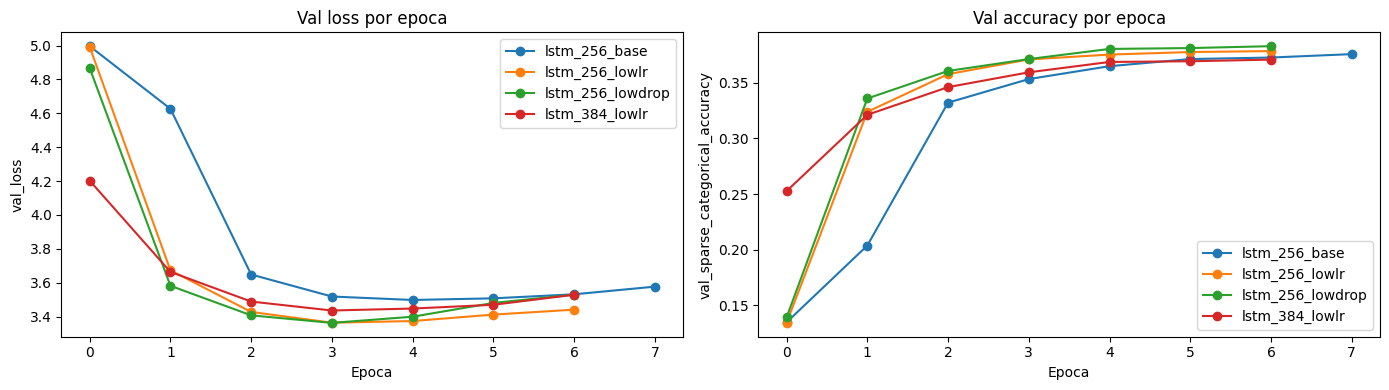

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model_name, hist_df in histories.items():
    axes[0].plot(hist_df['val_loss'].values, marker='o', label=model_name)
    axes[1].plot(hist_df['val_sparse_categorical_accuracy'].values, marker='o', label=model_name)

axes[0].set_title('Val loss por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('val_loss')
axes[0].legend()

axes[1].set_title('Val accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('val_sparse_categorical_accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fine_calibration_validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluacion con `BLEU`

Despues de seleccionar preliminarmente por `val_loss`, se compara el solapamiento textual sobre una muestra del conjunto de test.

In [10]:
index_word = tokenizer.index_word
start_token = tokenizer.word_index['startseq']
end_token = tokenizer.word_index['endseq']

loaded_models = {row.model_name: load_model(row.model_path) for row in results_df.itertuples(index=False)}


def generate_caption(image_name, model, tokenizer, image_features, max_len):
    feature_vector = image_features[image_name].reshape(1, -1)
    in_seq = [start_token]

    for _ in range(max_len):
        padded_seq = pad_sequences([in_seq], maxlen=max_len, padding='post')
        yhat = model.predict([feature_vector, padded_seq], verbose=0)
        next_idx = int(np.argmax(yhat[0]))

        if next_idx == 0:
            break

        next_word = index_word.get(next_idx, 'unk')
        if next_word == 'endseq':
            break

        in_seq.append(next_idx)

    words = [index_word.get(idx, 'unk') for idx in in_seq if idx not in (start_token, end_token)]
    return ' '.join(words)


def get_reference_captions(image_name, dataframe):
    refs = dataframe.loc[dataframe['image'] == image_name, 'caption_clean'].tolist()
    refs = [caption.replace('startseq ', '').replace(' endseq', '') for caption in refs]
    return refs

In [11]:
eval_images = test_df['image'].drop_duplicates().tolist()[:300]
bleu_rows = []

for model_name, model in loaded_models.items():
    references = []
    hypotheses = []

    for image_name in eval_images:
        refs = [caption.split() for caption in get_reference_captions(image_name, test_df)]
        hyp = generate_caption(image_name, model, tokenizer, image_features, max_len).split()
        references.append(refs)
        hypotheses.append(hyp)

    smoother = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
    bleu_rows.append({'model_name': model_name, 'BLEU-1': round(bleu1, 4), 'BLEU-2': round(bleu2, 4)})

bleu_df = pd.DataFrame(bleu_rows).sort_values(['BLEU-2', 'BLEU-1'], ascending=False).reset_index(drop=True)
bleu_df

2026-03-14 19:16:57.114240: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:16:57.983932: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:19:30.600536: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:19:30.777742: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:21:46.706570: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:21:46.886582: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:23:57.749989: I tensorflow/core/grappler/optimizers/cust

,model_name,BLEU-1,BLEU-2
0,lstm_384_lowlr,0.5425,0.3719
1,lstm_256_lowlr,0.5392,0.3715
2,lstm_256_base,0.5357,0.3638
3,lstm_256_lowdrop,0.4809,0.3331


In [12]:
results_df = results_df.merge(bleu_df, on='model_name', how='left')
results_df = results_df.sort_values(['best_val_loss', 'BLEU-2', 'BLEU-1'], ascending=[True, False, False]).reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / 'fine_calibration_results_final.csv', index=False)
results_df

,model_name,recurrent_units,embedding_dim,dropout_rate,learning_rate,best_epoch,best_val_loss,best_val_accuracy,train_loss_at_best_epoch,training_time_min,model_path,BLEU-1,BLEU-2
0,lstm_256_lowdrop,256,256,0.2,0.0010,4,3.3624,0.3714,2.8038,12.39,/Users/danilosuarezvargas/Documents/Maestria U...,0.4809,0.3331
1,lstm_256_lowlr,256,256,0.3,0.0005,4,3.3635,0.3710,2.9211,11.63,/Users/danilosuarezvargas/Documents/Maestria U...,0.5392,0.3715
2,lstm_384_lowlr,384,256,0.3,0.0005,4,3.4355,0.3595,2.9109,12.85,/Users/danilosuarezvargas/Documents/Maestria U...,0.5425,0.3719
3,lstm_256_base,256,256,0.3,0.0010,5,3.4977,0.3650,2.8216,13.31,/Users/danilosuarezvargas/Documents/Maestria U...,0.5357,0.3638


## 5. Analisis cualitativo

Esta comparacion visual ayuda a entender si el modelo mejora en escenas ambiguas o si sigue generando captions demasiado genericos.

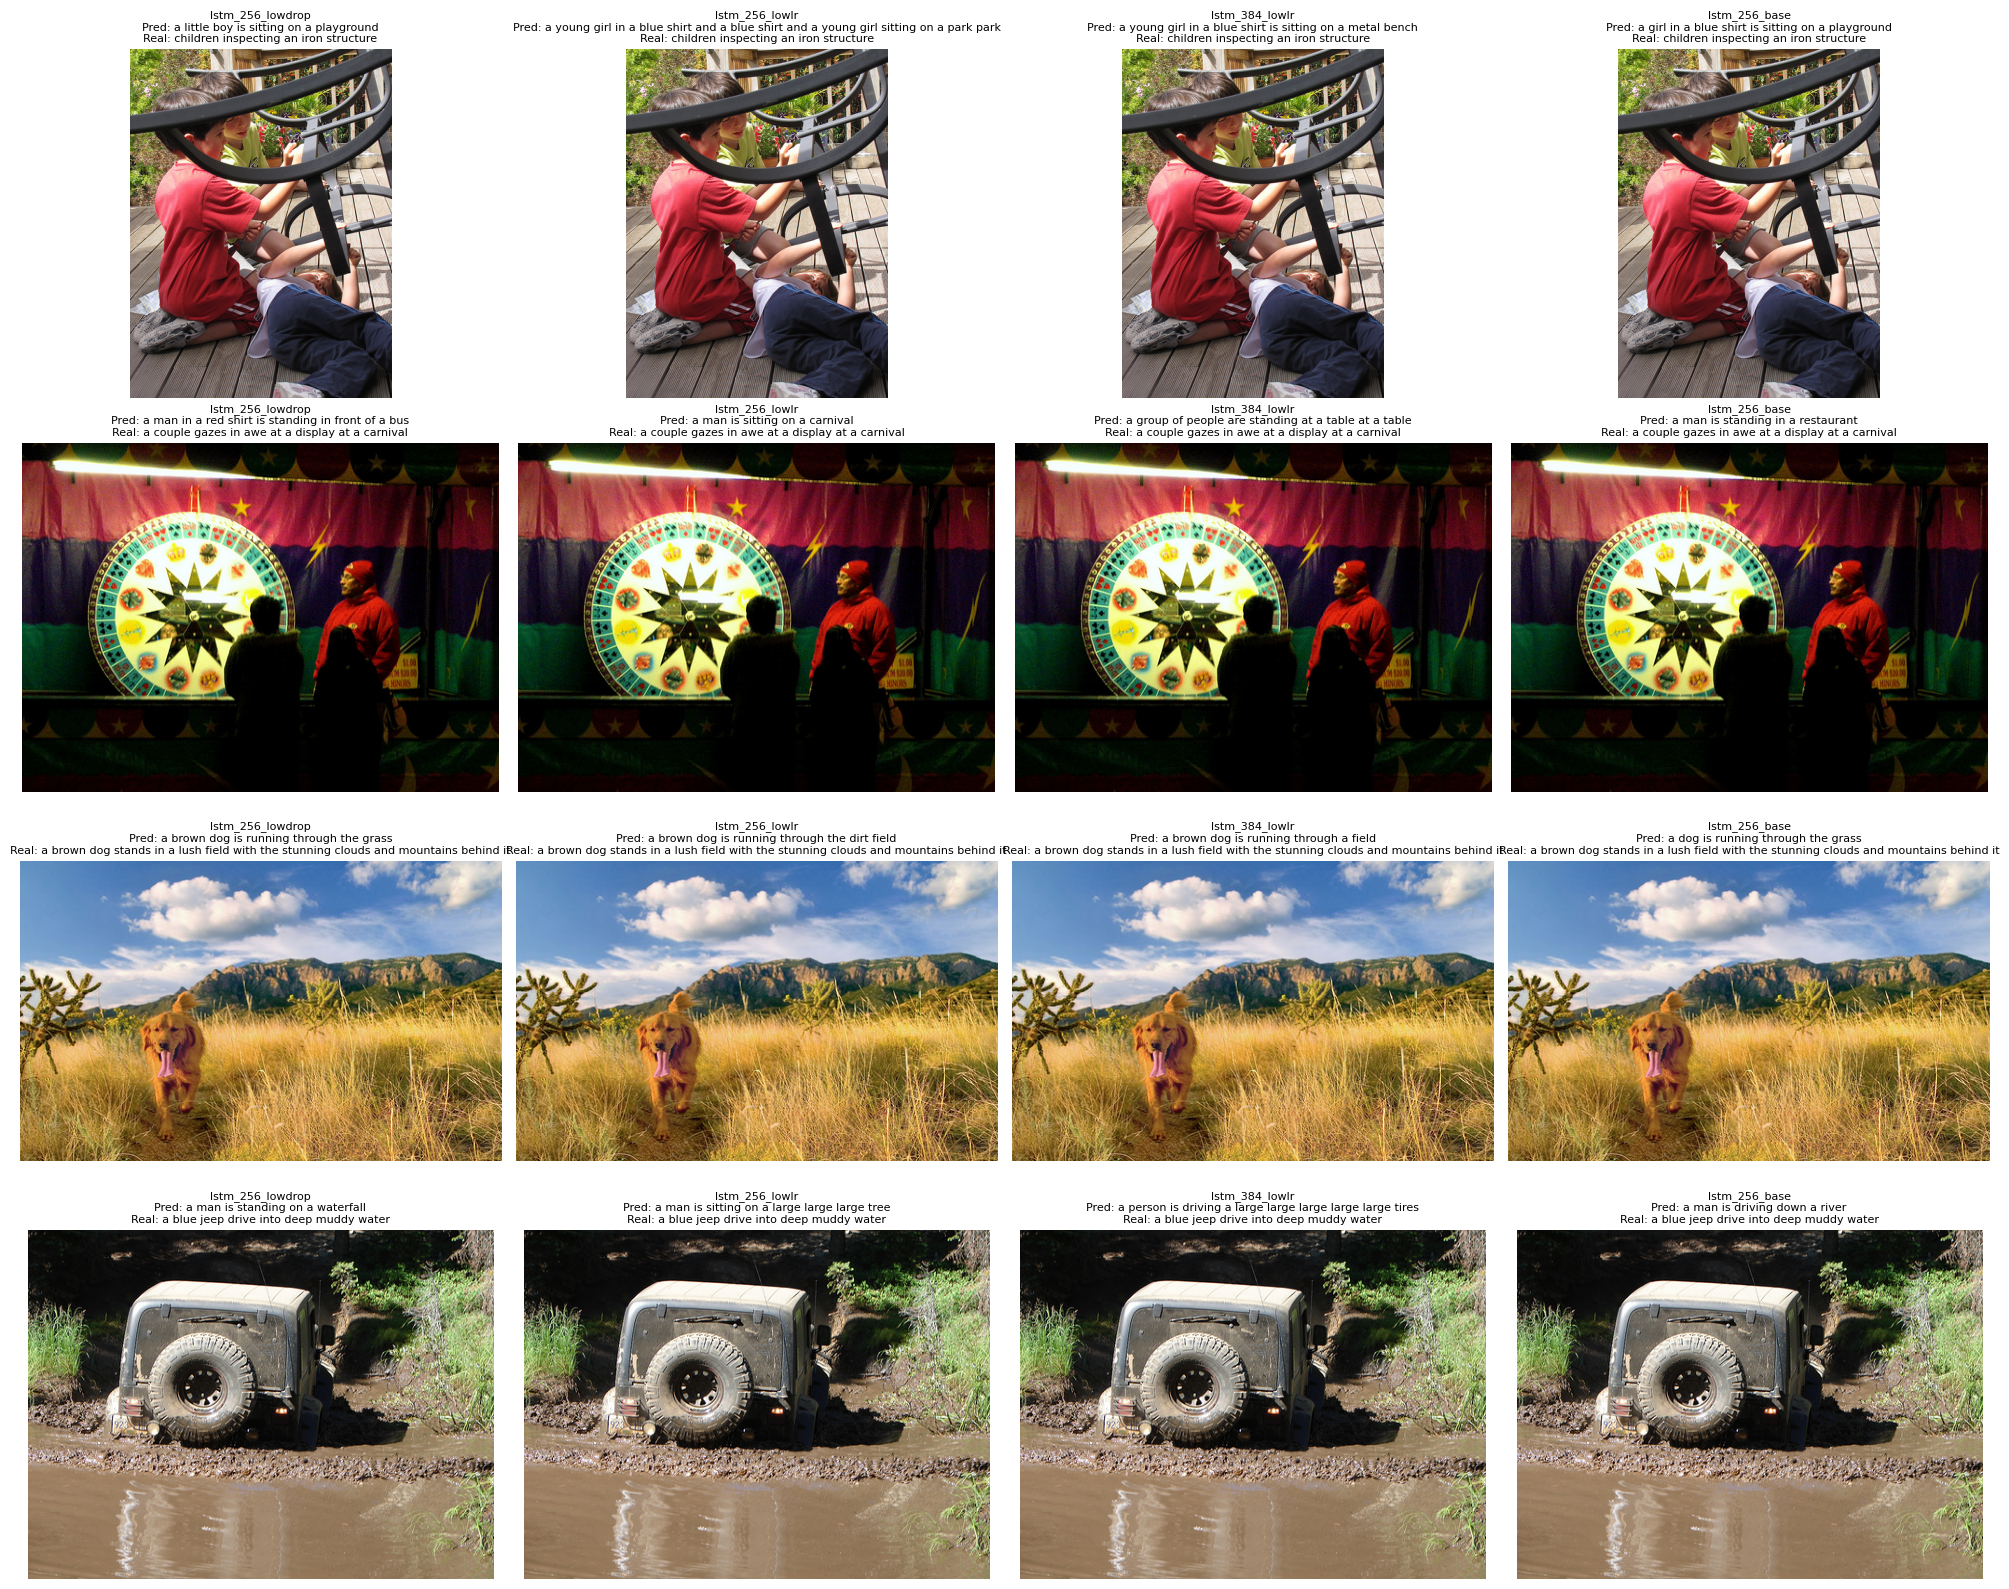

,image,model_name,prediction,reference_1
0,3317960829_78bbfafbb6.jpg,lstm_256_lowdrop,a little boy is sitting on a playground,children inspecting an iron structure
1,3317960829_78bbfafbb6.jpg,lstm_256_lowlr,a young girl in a blue shirt and a blue shirt ...,children inspecting an iron structure
2,3317960829_78bbfafbb6.jpg,lstm_384_lowlr,a young girl in a blue shirt is sitting on a m...,children inspecting an iron structure
3,3317960829_78bbfafbb6.jpg,lstm_256_base,a girl in a blue shirt is sitting on a playground,children inspecting an iron structure
4,3392019836_c7aeebca1c.jpg,lstm_256_lowdrop,a man in a red shirt is standing in front of a...,a couple gazes in awe at a display at a carnival


In [13]:
sample_images = test_df['image'].drop_duplicates().sample(4, random_state=42).tolist()
model_names = results_df['model_name'].tolist()

fig, axes = plt.subplots(len(sample_images), len(model_names), figsize=(5 * len(model_names), 4 * len(sample_images)))
axes = np.atleast_2d(axes)
qualitative_rows = []

for row_idx, image_name in enumerate(sample_images):
    refs = get_reference_captions(image_name, test_df)
    for col_idx, model_name in enumerate(model_names):
        ax = axes[row_idx, col_idx]
        pred = generate_caption(image_name, loaded_models[model_name], tokenizer, image_features, max_len)
        qualitative_rows.append({'image': image_name, 'model_name': model_name, 'prediction': pred, 'reference_1': refs[0]})
        ax.imshow(imread(IMG_DIR / image_name))
        ax.set_title(f"{model_name}\nPred: {pred}\nReal: {refs[0]}", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fine_calibration_qualitative_examples.png', dpi=150, bbox_inches='tight')
plt.show()

qualitative_df = pd.DataFrame(qualitative_rows)
qualitative_df.to_csv(OUTPUT_DIR / 'fine_calibration_qualitative_examples.csv', index=False)
qualitative_df.head()

## 6. Seleccion final del modelo

Interpretacion esperada:
- si una configuracion mejora `val_loss` y `BLEU`, se adopta como modelo final,
- si las mejoras son marginales, se puede preferir el modelo mas simple o el que tenga mejor costo-tiempo,
- si ningun modelo mejora al candidato previo, se conserva `lstm_256` del notebook 03 como mejor solucion encontrada.
